# BESTEST Cases 600–695 summary

Annual, peak, solar, and native-ISO results for the conditioned 6XX family.

In [1]:
from pathlib import Path
import sys,pandas as pd,matplotlib.pyplot as plt
from IPython.display import display
root=Path.cwd(); root=root if (root/'results').is_dir() else root.parent
sys.path.insert(0,str(root/'scripts'))
from case6xx_reporting import annual_tracks,comparison_table
CASES=('600','610','620','630','640','650','660','670','680','685','695')
metrics={case:pd.read_csv(root/'results'/f'case{case}'/f'case{case}_metrics.csv') for case in CASES}

## Annual heating and cooling

Heating MWh                                     Cooling MWh  \
Run  ISO + Modelica solar Modelica native Native ISO ISO + Modelica solar   
Case                                                                        
600              4.582236        4.657997   5.502373             5.727737   
610              4.714909        4.783806   5.648637             4.536569   
620              4.768045        4.823477   5.059147             3.967416   
630              5.052480        5.096715   5.259892             2.923182   
640              2.566110        2.898367   3.749936             5.430640   
650              0.000000        0.000000   0.000000             4.801365   
660              3.844761        3.898471   4.681826             3.134986   
670              7.302776        7.381270   8.637256             4.902492   
680              2.577225        2.646207   3.226216             6.696079   
685              4.982195        5.063028   5.773615             8.584864   
695              3.074243        3.146838   3.613432             9.265985   

                                 
Run  Modelica native Native ISO  
Case                             
600         5.802666   1.413772  
610         4.602160   1.186934  
620         4.009000   3.840018  
630         2.953847   2.798867  
640         5.616459   1.376850  
650         4.820687   1.054494  
660         3.184404   0.930337  
670         4.975308   1.233579  
680         6.764384   1.475017  
685         8.650902   3.452811  
695         9.323000   3.429614

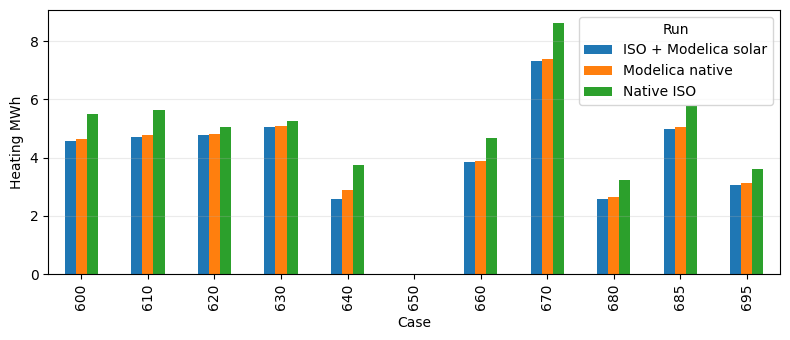

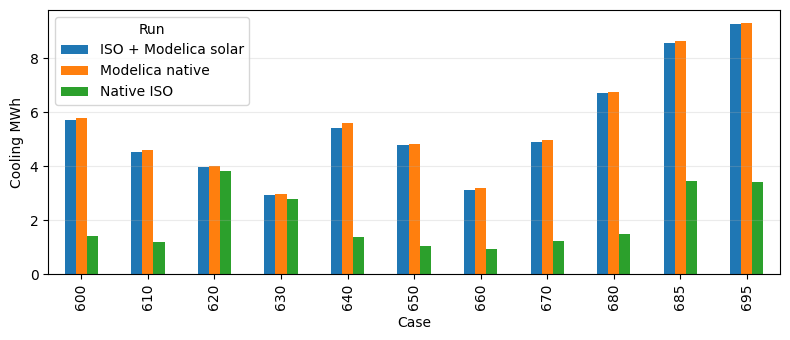

In [2]:
annual=pd.concat([annual_tracks(metrics[case]).assign(Case=case) for case in CASES]); display(annual.pivot(index='Case',columns='Run',values=['Heating MWh','Cooling MWh']))
for metric in ('Heating MWh','Cooling MWh'):
    fig,ax=plt.subplots(figsize=(8,3.5)); annual.pivot(index='Case',columns='Run',values=metric).plot(kind='bar',ax=ax); ax.set_ylabel(metric); ax.grid(axis='y',alpha=.25); fig.tight_layout(); plt.show()

## Controlled-forcing residuals and solar

In [3]:
residual=pd.concat([comparison_table(metrics[case],'controlled_modelica').assign(Case=case) for case in CASES]); display(residual.pivot(index='Case',columns='Metric',values='Difference %'))
solar=[]
for case in CASES:
    values=pd.read_csv(root/'results'/f'case{case}'/f'case{case}_solar_comparison.csv').set_index('quantity').value
    solar.append({'Case':case,'Native solar MWh':values['native_rclib_zone_solar_MWh'],'Modelica solar MWh':values['modelica_resolved_zone_solar_MWh']})
display(pd.DataFrame(solar))

Metric,Annual cooling,Annual heating,Peak cooling,Peak heating
Case,,,,
600,-1.291280,-1.626474,-0.965498,2.598121
610,-1.425217,-1.440204,-1.818391,2.574102
620,-1.037266,-1.149214,-0.015808,2.562344
630,-1.038147,-0.867901,0.177639,2.558191
640,-3.308475,-11.463583,-1.422972,6.687364
650,-0.400820,NaN,-1.810430,NaN
660,-1.551858,-1.377708,-1.639800,2.562575
670,-1.463552,-1.063421,-1.687834,2.626561
680,-1.009774,-2.606835,-0.957722,2.684564


,Case,Native solar MWh,Modelica solar MWh
0,600,4.270377,12.112389
1,610,3.653750,10.247074
2,620,8.625660,9.349927
3,630,6.771119,7.340286
4,640,4.270377,12.112389
5,650,4.270377,12.112389
6,660,2.655251,7.208074
7,670,4.297211,13.507168
8,680,3.972237,11.562587
9,685,4.270377,12.112389
